In [38]:
import os
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = Path("../estimator_results")

# Map numeric size (in billions) to directory name fragment.
# To add a new size, just add an entry here.
MODEL_SIZES: dict[float, str] = {
    1.7: "Qwen3-1_7B-non-thinking",
    4: "Qwen3-4B-non-thinking",
    8: "Qwen3-8B-non-thinking",
    14: "Qwen3-14B-non-thinking",
}

DATASETS = [
    "triviaqa-validation",
    "simpleqa-verified",
    "gsm8k-test",
    "math-500",
    "aime25-test",
    "mmlu-validation",
    "gpqa-diamond",
]

# Each method maps to a function that returns the path to evaluation_metrics.json
# given the base dir, dataset name, and model dir fragment.
# To add a new method, add an entry here.
METHODS: dict[str, callable] = {
    "verbalized_confidence": lambda base, ds, model: base / "verbalized_confidence" / (f"{ds}__{model}__RTXPro6000" if model == "Qwen3-8B-non-thinking" else f"{ds}__{model}") / "evaluation_metrics.json",
    "ptrue": lambda base, ds, model: base / "ptrue" / (f"{ds}__{model}__RTXPro6000" if model == "Qwen3-8B-non-thinking" else f"{ds}__{model}") / "evaluation_metrics.json",
    # Future probe methods — uncomment and adjust path pattern when data is available:
    "probe_triviaqa": lambda base, ds, model: base / "linear_probe" / f"{model}__trained-on-triviaqa-train" / f"{ds}" / "metrics.json",
    "probe_gsm8k": lambda base, ds, model: base / "linear_probe" / f"{model}__trained-on-gsm8k-train" / f"{ds}" / "metrics.json",
    "probe_math": lambda base, ds, model: base / "linear_probe" / f"{model}__trained-on-math-train" / f"{ds}" / "metrics.json",
}

METRICS = ["mse", "spearman_r"]

# X-axis tick labels for all planned sizes (shown even if no data yet)
ALL_SIZES = [1.7, 4, 8, 14]
SIZE_LABELS = {1.7: "1.7B", 4: "4B", 8: "8B", 14: "14B"}

In [39]:
# data[method][metric][dataset] -> list of (size, value) pairs
data: dict[str, dict[str, dict[str, list[tuple[float, float]]]]] = {}

for method_name, path_fn in METHODS.items():
    data[method_name] = {m: {} for m in METRICS}
    for dataset in DATASETS:
        for metric in METRICS:
            data[method_name][metric][dataset] = []
        for size, model_dir in sorted(MODEL_SIZES.items()):
            fpath = path_fn(BASE_DIR, dataset, model_dir)
            if not fpath.exists():
                continue
            with open(fpath) as f:
                metrics = json.load(f)
            for metric in METRICS:
                if metric in metrics:
                    data[method_name][metric][dataset].append((size, metrics[metric]))

# Quick sanity check
for method_name in data:
    for metric in METRICS:
        n_points = sum(len(v) for v in data[method_name][metric].values())
        print(f"{method_name} / {metric}: {n_points} data points")

verbalized_confidence / mse: 28 data points
verbalized_confidence / spearman_r: 28 data points
ptrue / mse: 28 data points
ptrue / spearman_r: 28 data points
probe_triviaqa / mse: 28 data points
probe_triviaqa / spearman_r: 28 data points
probe_gsm8k / mse: 28 data points
probe_gsm8k / spearman_r: 28 data points
probe_math / mse: 28 data points
probe_math / spearman_r: 28 data points


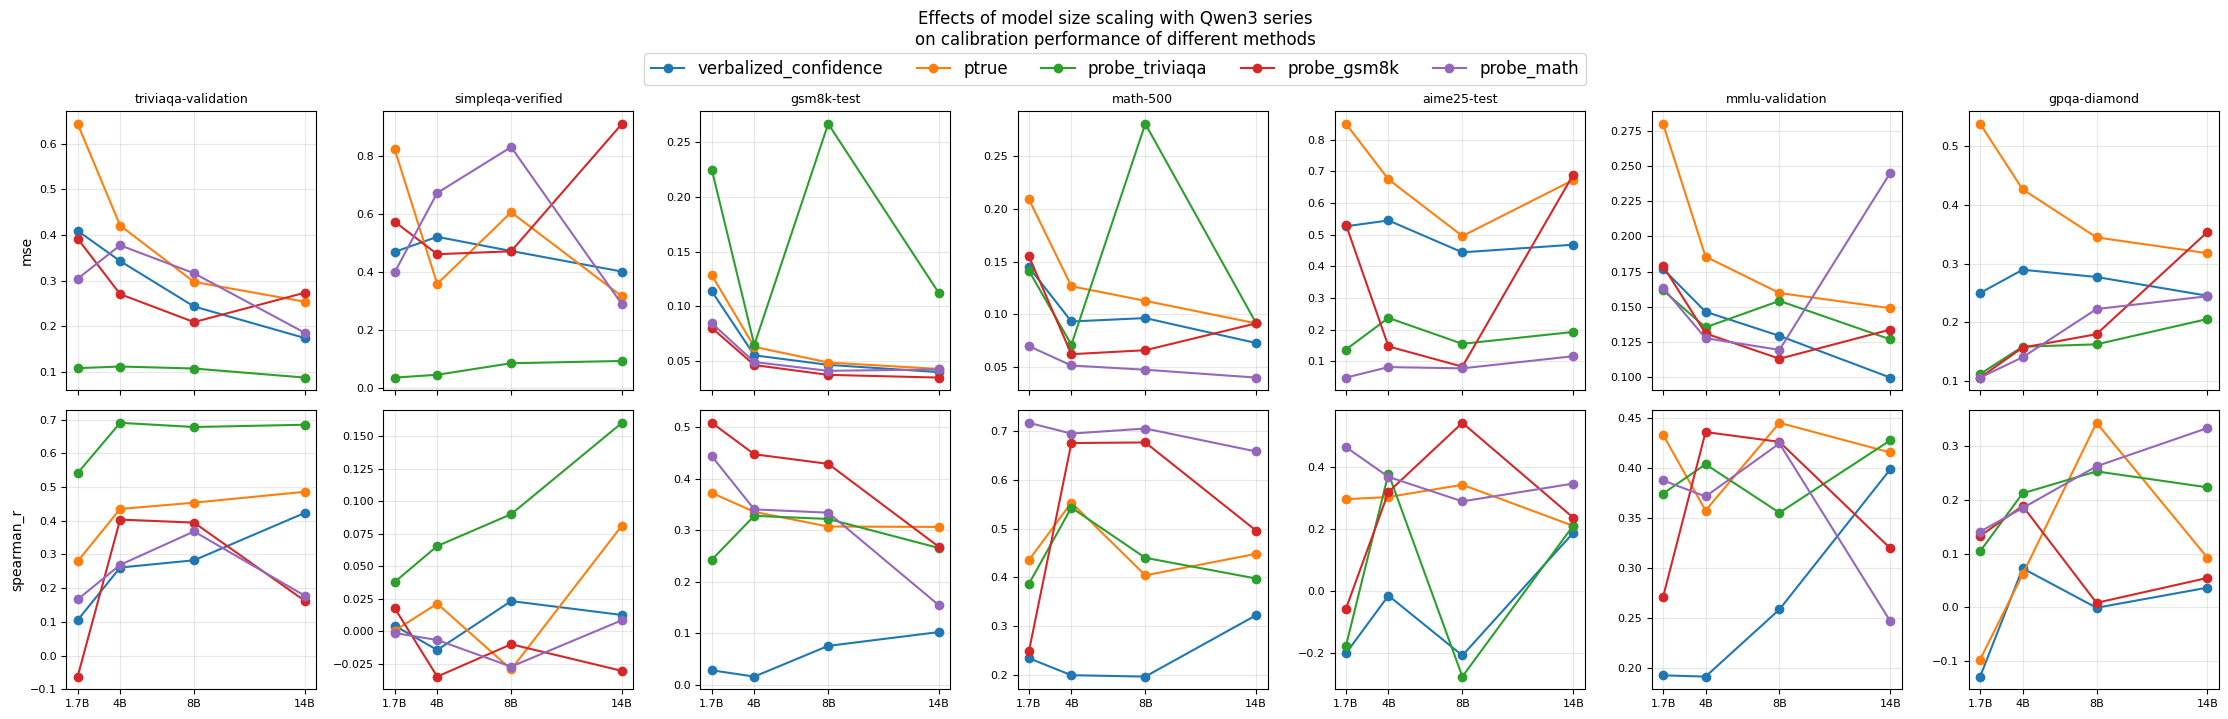

In [40]:
fig, axes = plt.subplots(
    len(METRICS), len(DATASETS),
    figsize=(3.2 * len(DATASETS), 3.5 * len(METRICS)),
    sharex=True,
    squeeze=False,
)

sizes_with_data = sorted(MODEL_SIZES.keys())

for row_idx, metric in enumerate(METRICS):
    for col_idx, dataset in enumerate(DATASETS):
        ax = axes[row_idx, col_idx]
        for method_name in METHODS:
            points = data[method_name][metric][dataset]
            if not points:
                continue
            xs, ys = zip(*points)
            ax.plot(xs, ys, marker="o", label=method_name)

        ax.set_xticks(sizes_with_data)
        ax.set_xticklabels([SIZE_LABELS.get(s, str(s)) for s in sizes_with_data], fontsize=8)

        if row_idx == 0:
            ax.set_title(dataset, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(metric, fontsize=10)

        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)

# Shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(METHODS), fontsize=12,
           bbox_to_anchor=(0.5, 0.97))

fig.suptitle(
    "Effects of model size scaling with Qwen3 series\non calibration performance of different methods",
    fontsize=12, y=1.02,
)
fig.tight_layout()
plt.savefig("model_scaling_calibration.pdf", bbox_inches="tight", dpi=150)
plt.show()